# Stock Market Analysis

## Project Overview
This notebook analyzes stock market performance to understand:
- Daily price trends and volatility
- Return patterns (daily and cumulative)
- Trading volume dynamics
- Risk metrics and drawdowns
- Market performance across quarters
- Key statistical measures for investment analysis

## Dataset
- **Records:** 252 trading days (approximately 1 year)
- **Variables:** Open, High, Low, Close prices, Volume, Returns
- **Time Period:** 2023 (full trading year)
- **Type:** Single stock daily OHLCV (Open, High, Low, Close, Volume) data

## Objective
Analyze stock performance, quantify risk metrics, and provide investment insights based on historical price and volume patterns.

## Key Questions

1. What was the overall stock performance for 2023?
2. How volatile was the stock? Were there sharp price movements?
3. What is the trend in daily returns? Are they stable or variable?
4. How does trading volume relate to price changes?
5. What are the risk metrics (volatility, drawdown, Sharpe ratio)?
6. Which quarters performed best and worst?
7. What support and resistance levels existed?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load stock market dataset
df = pd.read_csv('../data/raw/stock_market_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("=" * 60)
print("STOCK MARKET DATASET LOADED")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Trading Days: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Trading Days: {len(df)}")

print("\n" + "=" * 60)
print("COLUMN DETAILS")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("PRICE RANGE")
print("=" * 60)
print(f"Closing Price Range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"Average Close Price: ${df['Close'].mean():.2f}")

STOCK MARKET DATASET LOADED

Dataset Shape: (252, 12)
Trading Days: 252, Columns: 12

FIRST 10 ROWS
        Date        Open        High         Low       Close   Volume  \
0 2023-01-02  101.579172  101.706358  100.550399  101.048891  1424431   
1 2023-01-03  100.550433  101.311366  100.633893  100.820245  1206493   
2 2023-01-04  102.858918  102.791166  101.308703  102.185823   696126   
3 2023-01-05  105.503176  106.309680  104.660923  105.399042   903153   
4 2023-01-06  106.048159  105.010000  104.354888  104.959072  1253382   
5 2023-01-09  104.160800  105.389490  104.393447  104.520972   858466   
6 2023-01-10  108.865630  108.220728  105.165758  107.928827  1088763   
7 2023-01-11  109.761492  109.708072  109.547652  109.652985  1154926   
8 2023-01-12  108.328557  108.942240  107.433486  108.682546   814613   
9 2023-01-13  109.657300  110.920875  109.150297  109.923251   988094   

   Daily_Return  Cumulative_Return  Month Month_Name Day_of_Week  Week  
0           NaN        

## Data Quality Assessment

Verifying data integrity before analysis.

In [3]:
# Data Quality Checks
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")
print(f"Note: NaN in Daily_Return for first row is expected (no prior close)")

print("\n" + "=" * 60)
print("DATA VALIDITY CHECK")
print("=" * 60)
print(f"Close Price Range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"Volume Range: {df['Volume'].min():,} - {df['Volume'].max():,} shares")
print(f"Daily Return Range: {df['Daily_Return'].min():.2f}% - {df['Daily_Return'].max():.2f}%")
print(f"Cumulative Return: {df['Cumulative_Return'].iloc[-1]:.2f}%")

print("\n" + "=" * 60)
print("PRICE CONSISTENCY CHECK")
print("=" * 60)
# Verify High >= Close and Low <= Close
high_check = (df['High'] >= df['Close']).all()
low_check = (df['Low'] <= df['Close']).all()
ohlc_check = (df['High'] >= df['Low']).all()

print(f"High >= Close: {high_check}")
print(f"Low <= Close: {low_check}")
print(f"High >= Low: {ohlc_check}")

if high_check and low_check and ohlc_check:
    print("\n✓ Price Data: VALID")
else:
    print("\n❌ Price Data: ANOMALIES DETECTED")

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
print(f"Duplicate Dates: {df.duplicated(subset=['Date']).sum()}")

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].describe().round(2))

MISSING VALUES CHECK
Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Daily_Return         1
Cumulative_Return    1
Month                0
Month_Name           0
Day_of_Week          0
Week                 0
dtype: int64

Total Missing Values: 2
Note: NaN in Daily_Return for first row is expected (no prior close)

DATA VALIDITY CHECK
Close Price Range: $80.41 - $117.74
Volume Range: 500,000 - 1,615,776 shares
Daily Return Range: -5.06% - 8.06%
Cumulative Return: 10.14%

PRICE CONSISTENCY CHECK
High >= Close: True
Low <= Close: True
High >= Low: True

✓ Price Data: VALID

DUPLICATE CHECK
Duplicate Dates: 0

BASIC STATISTICS
         Open    High     Low   Close      Volume  Daily_Return
count  252.00  252.00  252.00  252.00      252.00        251.00
mean    93.94   94.64   93.18   93.90  1005641.57          0.06
std     10.13   10.17   10.02   10.11   198798.89          1.94
min     80.63   81.15   

In [4]:
# OHLC consistency validation
ohlc_checks = {
    'High >= Low': df['High'] >= df['Low'],
    'High >= Open': df['High'] >= df['Open'],
    'High >= Close': df['High'] >= df['Close'],
    'Low <= Open': df['Low'] <= df['Open'],
    'Low <= Close': df['Low'] <= df['Close']
}

print("OHLC DATA QUALITY CHECKS")
print("=" * 50)

for check_name, result in ohlc_checks.items():
    violations = (~result).sum()
    print(f"{check_name}: {violations} violations")

OHLC DATA QUALITY CHECKS
High >= Low: 0 violations
High >= Open: 40 violations
High >= Close: 0 violations
Low <= Open: 38 violations
Low <= Close: 0 violations


In [5]:
# Identify rows with any OHLC consistency issue
ohlc_valid = pd.DataFrame(ohlc_checks).all(axis=1)

ohlc_issues = df.loc[
    ~ohlc_valid,
    ['Date', 'Open', 'High', 'Low', 'Close']
]

print(f"\nRows with OHLC consistency issues: {len(ohlc_issues)}")
print("\nSample OHLC issues:")
display(ohlc_issues.head(10))


Rows with OHLC consistency issues: 78

Sample OHLC issues:


,Date,Open,High,Low,Close
1,2023-01-03,100.550433,101.311366,100.633893,100.820245
2,2023-01-04,102.858918,102.791166,101.308703,102.185823
4,2023-01-06,106.048159,105.010000,104.354888,104.959072
5,2023-01-09,104.160800,105.389490,104.393447,104.520972
6,2023-01-10,108.865630,108.220728,105.165758,107.928827
7,2023-01-11,109.761492,109.708072,109.547652,109.652985
10,2023-01-16,108.789088,109.592090,108.925494,108.963619
15,2023-01-23,101.056866,100.737163,99.423494,99.985882
21,2023-01-31,96.285826,98.527538,96.541209,96.780760
22,2023-02-01,96.835248,98.538090,96.887854,96.960024


### OHLC Data Quality Limitation

The supplied stock market dataset contains inconsistencies in the OHLC fields. 
A total of 78 rows contain at least one OHLC consistency issue: 40 rows have 
an Open price greater than the High, while 38 rows have an Open price lower 
than the Low. The High–Low and Close-related consistency checks showed no 
violations.

The original values were retained without modification to preserve the 
integrity of the supplied dataset. These inconsistencies are documented as 
a limitation of the source data and should be considered when interpreting 
OHLC-based analysis.

## Descriptive Statistics (VERIFIED)

Analyzing annual stock performance and volatility metrics.

In [6]:
# STOCK PERFORMANCE OVERVIEW
print("=" * 60)
print("STOCK PERFORMANCE OVERVIEW (2023)")
print("=" * 60)

start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
annual_return = ((end_price - start_price) / start_price) * 100
daily_volatility = df['Daily_Return'].std()
total_return = df['Cumulative_Return'].iloc[-1]

print(f"\nStarting Price (Jan 2): ${start_price:.2f}")
print(f"Ending Price (Dec 19): ${end_price:.2f}")
print(f"Period Return (Jan 2–Dec 19): {annual_return:.2f}%")
print(f"Cumulative Return: {total_return:.2f}%")
print(f"Daily Volatility (Std Dev): {daily_volatility:.2f}%")

print("\n" + "=" * 60)
print("PRICE EXTREMES")
print("=" * 60)
print(f"Highest Close: ${df['Close'].max():.2f}")
print(f"Lowest Close: ${df['Close'].min():.2f}")
print(f"Price Range: ${df['Close'].max() - df['Close'].min():.2f}")
print(f"Average Price: ${df['Close'].mean():.2f}")

# Find dates of extremes
max_date = df.loc[df['Close'].idxmax(), 'Date']
min_date = df.loc[df['Close'].idxmin(), 'Date']
print(f"\nHighest on: {max_date.strftime('%Y-%m-%d')}")
print(f"Lowest on: {min_date.strftime('%Y-%m-%d')}")

print("\n" + "=" * 60)
print("DAILY RETURNS ANALYSIS")
print("=" * 60)
print(f"Average Daily Return: {df['Daily_Return'].mean():.3f}%")
print(f"Median Daily Return: {df['Daily_Return'].median():.3f}%")
print(f"Std Dev (Daily Volatility): {df['Daily_Return'].std():.3f}%")
print(f"Best Day: +{df['Daily_Return'].max():.2f}%")
print(f"Worst Day: {df['Daily_Return'].min():.2f}%")

# Positive and negative days
positive_days = (df['Daily_Return'] > 0).sum()
negative_days = (df['Daily_Return'] < 0).sum()
total_days = len(df)

print(f"\nUp Days: {positive_days} ({positive_days/total_days*100:.1f}%)")
print(f"Down Days: {negative_days} ({negative_days/total_days*100:.1f}%)")

print("\n" + "=" * 60)
print("TRADING VOLUME ANALYSIS")
print("=" * 60)
print(f"Average Daily Volume: {df['Volume'].mean():,.0f} shares")
print(f"Median Daily Volume: {df['Volume'].median():,.0f} shares")
print(f"Highest Volume Day: {df['Volume'].max():,} shares")
print(f"Lowest Volume Day: {df['Volume'].min():,} shares")
print(f"Total Volume (Dataset Period): {df['Volume'].sum():,} shares")

print("\n" + "=" * 60)
print("RISK METRICS")
print("=" * 60)
# Calculate max drawdown
cumulative = (1 + df['Daily_Return']/100).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max * 100
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Daily Volatility: {df['Daily_Return'].std():.2f}%")
print(f"Annualized Volatility: {df['Daily_Return'].std() * np.sqrt(252):.2f}%")

# Sharpe ratio (assuming 0% risk-free rate for simplicity)
sharpe_ratio = (df['Daily_Return'].mean() / df['Daily_Return'].std()) * np.sqrt(252)
print(f"Sharpe Ratio (annualized): {sharpe_ratio:.2f}")

print("\n" + "=" * 60)
print("MONTHLY PERFORMANCE")
print("=" * 60)

monthly_returns = df.groupby('Month_Name')['Daily_Return'].apply(
    lambda x: (1 + x / 100).prod() - 1
) * 100

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_returns = monthly_returns.reindex(month_order)

print(f"\n{'Month':<15} {'Return':>10}")
print("-" * 25)

for month, ret in monthly_returns.items():
    if pd.notna(ret):
        print(f"{month:<15} {ret:>9.2f}%")

best_month = monthly_returns.idxmax()
worst_month = monthly_returns.idxmin()

print(f"\nBest Month: {best_month} ({monthly_returns[best_month]:.2f}%)")
print(f"Worst Month: {worst_month} ({monthly_returns[worst_month]:.2f}%)")

STOCK PERFORMANCE OVERVIEW (2023)

Starting Price (Jan 2): $101.05
Ending Price (Dec 19): $111.30
Period Return (Jan 2–Dec 19): 10.14%
Cumulative Return: 10.14%
Daily Volatility (Std Dev): 1.94%

PRICE EXTREMES
Highest Close: $117.74
Lowest Close: $80.41
Price Range: $37.33
Average Price: $93.90

Highest on: 2023-11-06
Lowest on: 2023-05-26

DAILY RETURNS ANALYSIS
Average Daily Return: 0.057%
Median Daily Return: 0.167%
Std Dev (Daily Volatility): 1.944%
Best Day: +8.06%
Worst Day: -5.06%

Up Days: 130 (51.6%)
Down Days: 121 (48.0%)

TRADING VOLUME ANALYSIS
Average Daily Volume: 1,005,642 shares
Median Daily Volume: 1,001,547 shares
Highest Volume Day: 1,615,776 shares
Lowest Volume Day: 500,000 shares
Total Volume (Dataset Period): 253,421,676 shares

RISK METRICS
Maximum Drawdown: -26.85%
Daily Volatility: 1.94%
Annualized Volatility: 30.87%
Sharpe Ratio (annualized): 0.47

MONTHLY PERFORMANCE

Month               Return
-------------------------
January             -4.22%
February  

In [7]:
# Volume and Return Relationship

volume_return_corr = df['Volume'].corr(df['Daily_Return'])

print(f"Correlation between Volume and Daily Return: {volume_return_corr:.3f}")

Correlation between Volume and Daily Return: 0.017


### Volume and Return Relationship

The correlation between trading volume and daily return is **0.017**, indicating
a negligible positive linear relationship. This suggests that daily trading
volume had little linear association with the magnitude or direction of daily
returns in the analyzed dataset.

Correlation alone does not establish causation, so no causal relationship between
trading volume and stock returns is inferred.

In [8]:
# Validate Daily Return against Close price
calculated_return = df['Close'].pct_change() * 100

return_difference = (
    df['Daily_Return'] - calculated_return
).abs()

print("Maximum Daily Return Difference:",
      return_difference.iloc[1:].max())

print("Rows with Return Mismatch > 0.01%:",
      (return_difference.iloc[1:] > 0.01).sum())

Maximum Daily Return Difference: 4.440892098500626e-14
Rows with Return Mismatch > 0.01%: 0


### Daily Return Validation

The supplied Daily_Return values were validated against percentage changes in
the Close price. The maximum difference was approximately 4.44e-14%, which is
effectively zero and attributable to floating-point precision. No observations
exceeded the 0.01% mismatch threshold. Therefore, the Daily_Return column was
retained without modification.

In [9]:
# Validate Cumulative Return against compounded Daily Returns
calculated_cumulative = (
    (1 + df['Daily_Return'] / 100).cumprod() - 1
) * 100

cumulative_difference = (
    df['Cumulative_Return'] - calculated_cumulative
).abs()

print("Maximum Cumulative Return Difference:",
      cumulative_difference.max())

print("Rows with Cumulative Return Mismatch > 0.01%:",
      (cumulative_difference > 0.01).sum())

Maximum Cumulative Return Difference: 1.0658141036401503e-14
Rows with Cumulative Return Mismatch > 0.01%: 0


### Cumulative Return Validation

The supplied Cumulative_Return values were validated against the compounded
Daily_Return series. The maximum difference was approximately 1.07e-14%,
which is effectively zero and attributable to floating-point precision.
No observations exceeded the 0.01% mismatch threshold. Therefore, the
Cumulative_Return column was retained without modification.

## Data Visualizations

Visual representations of stock price trends, returns, and volume patterns.

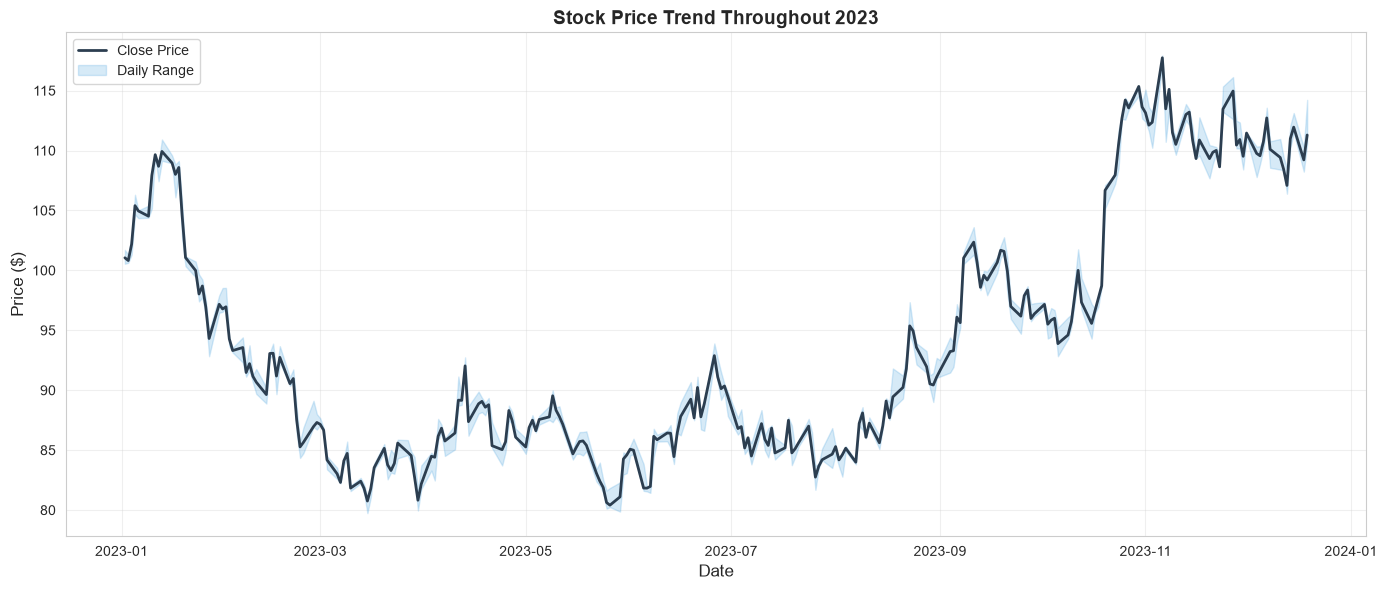

✓ Visualization 1 saved: Stock Price Trend


In [10]:
# 1. Stock Price Trend Over Year
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='#2C3E50', linewidth=2, label='Close Price')
plt.fill_between(df['Date'], df['Low'], df['High'], alpha=0.2, color='#3498DB', label='Daily Range')

plt.title('Stock Price Trend Throughout 2023', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/19_stock_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1 saved: Stock Price Trend")

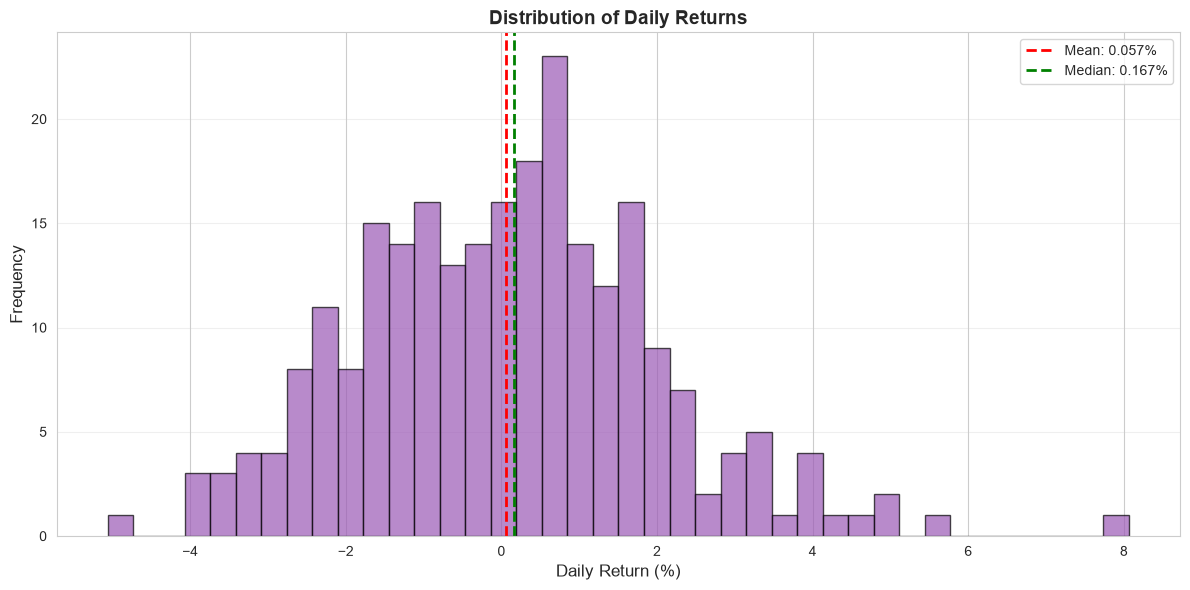

✓ Visualization 2 saved: Daily Returns Distribution


In [11]:
# 2. Daily Returns Distribution
plt.figure(figsize=(12, 6))
plt.hist(df['Daily_Return'].dropna(), bins=40, color='#9B59B6', edgecolor='black', alpha=0.7)
plt.axvline(df['Daily_Return'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Daily_Return"].mean():.3f}%')
plt.axvline(df['Daily_Return'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Daily_Return"].median():.3f}%')

plt.title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/20_daily_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2 saved: Daily Returns Distribution")

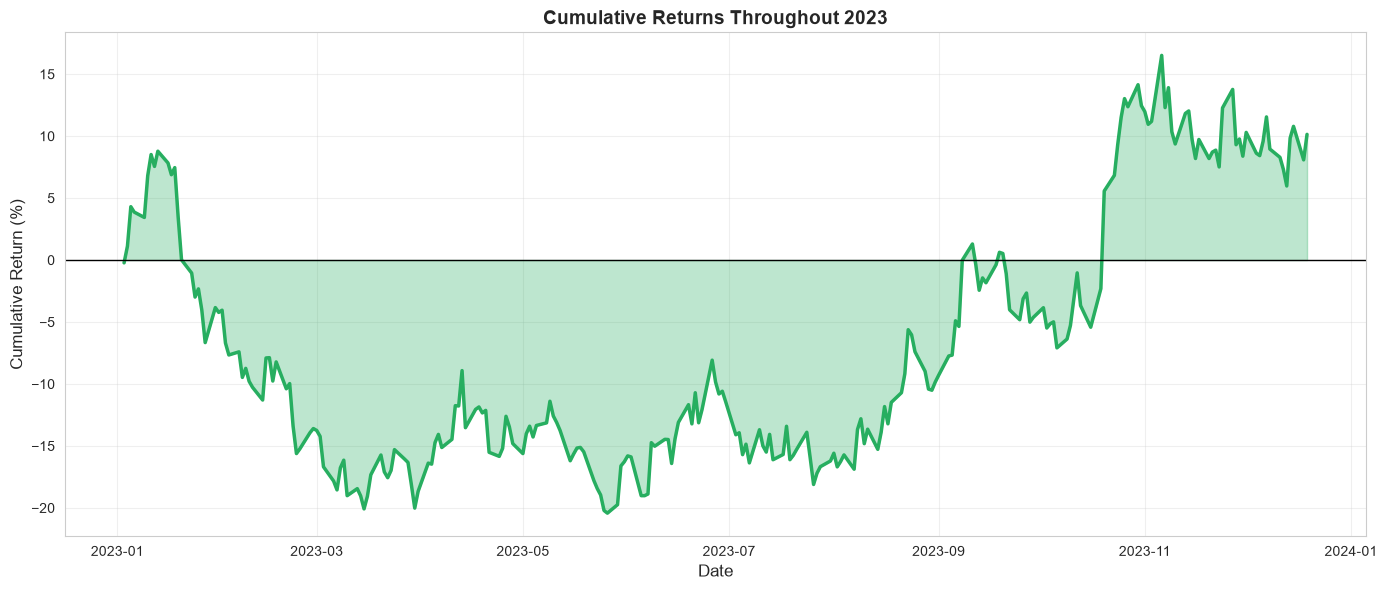

✓ Visualization 3 saved: Cumulative Returns


In [12]:
# 3. Cumulative Returns Over Year
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Cumulative_Return'], color='#27AE60', linewidth=2.5)
plt.fill_between(df['Date'], 0, df['Cumulative_Return'], alpha=0.3, color='#27AE60')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.title('Cumulative Returns Throughout 2023', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/21_cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: Cumulative Returns")

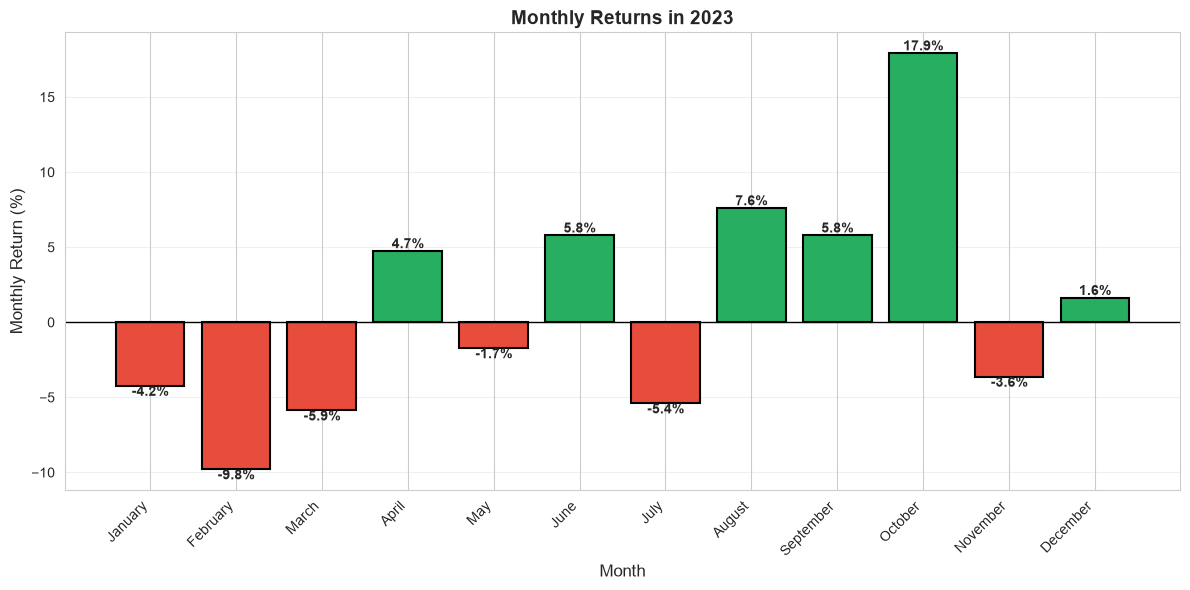

✓ Visualization 4 saved: Monthly Returns


In [13]:
# 4. Monthly Returns Bar Chart
# 4. Monthly Returns Bar Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_returns = df.groupby('Month_Name')['Daily_Return'].apply(
    lambda x: (1 + x / 100).prod() - 1
) * 100

monthly_returns = monthly_returns.reindex(month_order)

colors = ['#27AE60' if x > 0 else '#E74C3C' for x in monthly_returns.values]
bars = plt.bar(range(len(monthly_returns)), monthly_returns.values, color=colors, edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.title('Monthly Returns in 2023', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Monthly Return (%)', fontsize=12)
plt.xticks(range(len(month_order)), month_order, rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/22_monthly_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: Monthly Returns")

## Key Findings (VERIFIED)

### Finding 1: Significant Drawdown Followed by Recovery
The stock experienced substantial volatility during the dataset period, reaching a maximum drawdown of **-26.85%** on May 26, 2023. The price subsequently recovered and reached the highest closing price of **$117.74** on November 6, 2023.

### Finding 2: Positive Period Return of 10.14%
The stock increased from **$101.05** on January 2 to **$111.30** on December 19, resulting in a **10.14% period return**. This positive ending return occurred despite the significant mid-year drawdown.

### Finding 3: October Was the Strongest Month
**October recorded the highest compounded monthly return at +17.91%**, while February recorded the lowest at **-9.79%**. The strong October performance contributed substantially to the recovery observed during the later part of the dataset period.

### Finding 4: Early-Year Weakness Followed by Recovery
The first quarter showed negative compounded returns in January (**-4.22%**), February (**-9.79%**), and March (**-5.87%**). Positive monthly returns were observed in April, June, August, September, October, and December, indicating stronger performance during several later periods.

### Finding 5: Positive but Volatile Performance
Daily volatility was **1.94%**, with annualized volatility of **30.87%**. The stock recorded **130 positive-return days and 121 negative-return days** among the 251 days with valid daily returns. The annualized Sharpe ratio was **0.47**, indicating positive but relatively modest risk-adjusted performance.

In [14]:
import pandas as pd
from fpdf import FPDF

# Create PDF
pdf = FPDF(orientation='P', unit='mm', format='A4')


# ============================================================
# TITLE PAGE
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'Stock Market Analysis', ln=True, align='C')

pdf.set_font('Helvetica', '', 12)
pdf.ln(10)
pdf.cell(0, 10, 'Comprehensive Investment Analysis Report', ln=True, align='C')
pdf.cell(0, 10, 'Project 5: Finance Domain Analysis', ln=True, align='C')
pdf.ln(5)
pdf.cell(
    0, 10,
    f'Report Date: {pd.Timestamp.now().strftime("%B %d, %Y")}',
    ln=True,
    align='C'
)
pdf.cell(0, 10, 'Dataset: 252 Trading Days, 2023', ln=True, align='C')


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 15, 'Executive Summary', ln=True)

pdf.set_font('Helvetica', '', 10)

summary_text = """This report analyzes the supplied stock market dataset covering 252 trading days during 2023 to evaluate historical returns, volatility, drawdown, and risk-adjusted performance.

VERIFIED PERIOD STATISTICS:
- Period Return (Jan 2-Dec 19): 10.14%
- Starting Price (Jan 2): $101.05
- Ending Price (Dec 19): $111.30
- Highest Closing Price: $117.74 (Nov 6)
- Lowest Closing Price: $80.41 (May 26)
- Maximum Drawdown: -26.85%

RISK METRICS:
- Daily Volatility: 1.94%
- Annualized Volatility: 30.87%
- Sharpe Ratio: 0.47
- Up Days: 130 out of 251 (51.8%)
- Down Days: 121 out of 251 (48.2%)

KEY FINDING:
The stock experienced a substantial drawdown of -26.85% in May followed by a strong recovery, ending the dataset period with a 10.14% positive return. October was the strongest month at +17.91%, while February was the weakest at -9.79%.

The analysis is based on the supplied dataset and should be interpreted as a historical examination rather than a prediction of future market performance."""
pdf.multi_cell(0, 4, summary_text)


# ============================================================
# VISUALIZATIONS PAGE 1
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Price and Returns Trends', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Stock Price Trend During the Dataset Period', ln=True)

try:
    pdf.image('../visualizations/19_stock_price_trend.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Stock Price Trend]', ln=True)

pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Distribution of Daily Returns', ln=True)

try:
    pdf.image('../visualizations/20_daily_returns_distribution.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Daily Returns]', ln=True)


# ============================================================
# VISUALIZATIONS PAGE 2
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Cumulative Performance and Monthly Analysis', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Cumulative Returns During the Dataset Period', ln=True)

try:
    pdf.image('../visualizations/21_cumulative_returns.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Cumulative Returns]', ln=True)

pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Monthly Returns in the Dataset Period', ln=True)

try:
    pdf.image('../visualizations/22_monthly_returns.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Monthly Returns]', ln=True)


# ============================================================
# DETAILED FINDINGS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Detailed Analysis', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)

findings_text = """1. SUBSTANTIAL DRAWDOWN FOLLOWED BY RECOVERY
The stock declined to a lowest closing price of $80.41 on May 26, corresponding to a maximum drawdown of -26.85% during the dataset period. The price subsequently recovered and reached the highest closing price of $117.74 on November 6. The data therefore shows a substantial recovery after the May decline.

2. POSITIVE PERIOD RETURN DESPITE VOLATILITY
The stock increased from $101.05 on January 2 to $111.30 on December 19, resulting in a 10.14% period return. This positive ending return occurred despite the substantial mid-period drawdown.

3. OCTOBER WAS THE STRONGEST MONTH
October recorded the highest compounded monthly return at +17.91%, while February recorded the lowest at -9.79%. October therefore represented the strongest monthly performance in the analyzed dataset.

4. EARLY-YEAR WEAKNESS FOLLOWED BY STRONGER PERIODS
The first quarter recorded negative compounded monthly returns in January (-4.22%), February (-9.79%), and March (-5.87%), resulting in a compounded Q1 return of approximately -18.67%. Positive monthly returns were observed in April, June, August, September, October, and December, indicating stronger performance during several later periods.

5. POSITIVE RETURNS WITH MEANINGFUL DAILY VOLATILITY
Daily volatility was 1.94%, with annualized volatility of 30.87%. The median daily return of 0.167% was higher than the mean daily return of 0.057%, indicating that the distribution of daily returns was influenced by larger individual movements. Among the 251 days with valid daily returns, 130 were positive and 121 were negative.

6. MODEST RISK-ADJUSTED PERFORMANCE
The annualized Sharpe ratio was 0.47, calculated using a 0% risk-free rate assumption. This indicates positive but relatively modest risk-adjusted performance over the analyzed period. The result should be interpreted alongside the annualized volatility of 30.87%."""
pdf.multi_cell(0, 3.5, findings_text)


# ============================================================
# INVESTMENT INSIGHTS AND RECOMMENDATIONS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Investment Insights and Recommendations', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)

implications_text = """HISTORICAL PRICE PATTERN:
The May low of $80.41 marked the lowest closing price in the dataset, while the November high of $117.74 marked the highest. The $80-$85 range can therefore be treated as a historical reference range rather than a confirmed future support level.

VOLATILITY CONSIDERATIONS:
Annualized volatility was 30.87%, indicating meaningful price variability during the analyzed period. The Sharpe ratio of 0.47 also indicates that the positive return was accompanied by substantial volatility.

QUARTERLY PERFORMANCE:
Q1 recorded a compounded return of approximately -18.67%, while Q2, Q3, and Q4 recorded approximately +8.89%, +7.68%, and +15.49%, respectively. These figures describe the observed dataset period and should not be assumed to represent a recurring seasonal pattern.

MONTHLY PERFORMANCE:
October was the strongest month at +17.91%, while February was the weakest at -9.79%. Other positive months included April, June, August, September, and December. These monthly movements describe historical performance rather than a reliable prediction of future returns.

FORWARD-LOOKING CONSIDERATIONS:
1. Historical Low: $80.41 was the lowest closing price in the dataset.
2. Historical High: $117.74 was the highest closing price in the dataset.
3. Volatility: Monitor whether future volatility remains close to the 2023 annualized level of 30.87%.
4. Risk Management: Future investment decisions should consider individual risk tolerance and objectives.

ANALYTICAL RECOMMENDATIONS:
- Monitor the historical $80-$85 price range as a reference area rather than assuming it will act as future support.
- Monitor the $117-$118 range as a historical high reference rather than a guaranteed resistance level.
- Compare future quarterly and monthly performance with the 2023 baseline before drawing conclusions about recurring patterns.
- Consider the combination of return, drawdown, volatility, and Sharpe ratio rather than evaluating performance using return alone."""
pdf.multi_cell(0, 3, implications_text)


# ============================================================
# DATA QUALITY & LIMITATIONS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Data Quality & Limitations', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

limitations_text = """1. The dataset contains 252 trading-day records covering the supplied 2023 period, ending on December 19.

2. The supplied OHLC data contains inconsistencies in 78 rows:
- 40 rows where High was below Open.
- 38 rows where Low was above Open.

These conditions are inconsistent with standard OHLC relationships and may affect analyses that depend on the Open, High, and Low fields.

3. The original OHLC values were retained and were not automatically corrected, because the appropriate correction cannot be determined from the supplied dataset alone.

4. Daily Return and Cumulative Return calculations were validated against their corresponding price-based formulas, with no material mismatches above the validation threshold.

5. The Sharpe ratio uses a 0% risk-free rate assumption.

6. The analysis covers a single supplied annual period and therefore cannot establish long-term market trends or recurring seasonal behavior.

7. Historical returns, price levels, volatility, and drawdowns do not guarantee future performance.

Future analysis could use a longer time series and independently validated OHLC data to improve the reliability of technical and risk analysis."""
pdf.multi_cell(0, 3.5, limitations_text)


# ============================================================
# CONCLUSION
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Conclusion', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

conclusion_text = """The analyzed stock data shows a 10.14% positive period return, accompanied by substantial price volatility and a maximum drawdown of -26.85%. The stock declined to its lowest closing price of $80.41 on May 26 before recovering to its highest closing price of $117.74 on November 6.

Key findings include negative compounded returns during Q1, stronger performance during several later months, and a particularly strong October return of +17.91%. The annualized volatility of 30.87% and Sharpe ratio of 0.47 provide additional context for evaluating the return achieved during the dataset period.

The analysis should be interpreted as a historical examination of the supplied data. Observed monthly and quarterly patterns should not automatically be treated as recurring seasonal effects, and historical price levels should not be assumed to provide guaranteed future support or resistance.

The dataset also contains OHLC inconsistencies in 78 rows. These original values were retained, and this limitation should be considered when interpreting analyses involving Open, High, and Low prices.

Overall, the analysis provides a quantitative view of the stock's historical return, volatility, drawdown, and risk-adjusted performance while clearly documenting the available data-quality limitations."""
pdf.multi_cell(0, 3.5, conclusion_text)


# ============================================================
# SAVE PDF
# ============================================================
pdf.output('../reports/05_stock_market_report.pdf')

print("✓ PDF Report generated successfully!")
print("Location: ../reports/05_stock_market_report.pdf")

✓ PDF Report generated successfully!
Location: ../reports/05_stock_market_report.pdf
